In [5]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving test_energy_data.csv to test_energy_data.csv
Saving train_energy_data.csv to train_energy_data.csv
{'test_energy_data.csv': b'Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption\nResidential,24563,15,4,28.52,Weekday,2865.57\nCommercial,27583,56,23,23.07,Weekend,4283.8\nCommercial,45313,4,44,33.56,Weekday,5067.83\nResidential,41625,84,17,27.39,Weekend,4624.3\nResidential,36720,58,47,17.08,Weekday,4820.59\nIndustrial,31207,47,28,22.82,Weekday,5026.23\nResidential,39227,18,44,23.36,Weekend,4404.56\nResidential,7814,21,19,27.27,Weekday,2394.37\nIndustrial,20482,24,16,23.0,Weekend,3969.09\nIndustrial,21030,90,35,12.96,Weekday,5136.69\nCommercial,41401,87,15,15.54,Weekend,5162.33\nIndustrial,6279,23,41,10.77,Weekend,3810.09\nIndustrial,31963,2,20,23.53,Weekend,4400.48\nCommercial,29187,82,39,23.54,Weekday,4991.64\nIndustrial,13990,80,27,12.9,Weekend,4474.98\nResidential,8157,10,37,25.96,Weekday,2668.06\nIndustrial,27165,7

In [6]:
import pandas as pd
df = pd.read_csv("train_energy_data.csv")

In [ ]:
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [8]:
df = pd.get_dummies(
    df,
    columns=["Building Type","Day of Week"],
    drop_first=True
)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Square Footage             1000 non-null   int64  
 1   Number of Occupants        1000 non-null   int64  
 2   Appliances Used            1000 non-null   int64  
 3   Average Temperature        1000 non-null   float64
 4   Energy Consumption         1000 non-null   float64
 5   Building Type_Industrial   1000 non-null   bool   
 6   Building Type_Residential  1000 non-null   bool   
 7   Day of Week_Weekend        1000 non-null   bool   
dtypes: bool(3), float64(2), int64(3)
memory usage: 42.1 KB


In [10]:
X = df.drop("Energy Consumption",axis=1)

y = df["Energy Consumption"]

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(X_train,y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(X_test)

In [16]:
from sklearn.metrics import r2_score

print(
    r2_score(y_test,y_pred)
)

0.9999999997684504


In [17]:
results = pd.DataFrame(
{
    "Actual": y_test,
    "Predicted": y_pred
}
)

results.head()

,Actual,Predicted
521,4549.59,4549.598244
737,2842.91,2842.901083
740,5781.83,5781.847788
660,4773.54,4773.550577
411,3791.04,3791.050217


In [18]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9999999997684504


In [19]:
results.head(10)

,Actual,Predicted
521,4549.59,4549.598244
737,2842.91,2842.901083
740,5781.83,5781.847788
660,4773.54,4773.550577
411,3791.04,3791.050217
678,2470.59,2470.599330
626,5003.05,5003.049430
513,3314.12,3314.099859
859,5147.11,5147.100047
136,4298.92,4298.899998


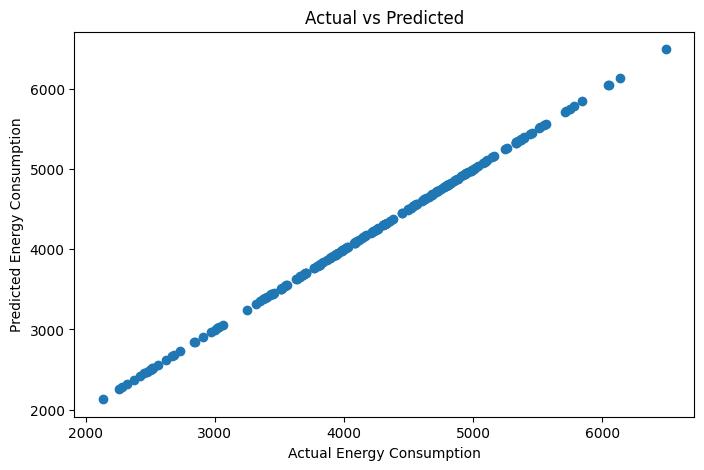

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted")
plt.show()